In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
from tqdm import tqdm

In [44]:
data=np.load('/home/kjaworski/Pulpit/Temporal_thermal_imaging/all_data_extrapolated/param_fbh_gaussian_size5mm_depth80pct_thickness6mm.npz',allow_pickle=True)
bscan=data['data'][:,200,:]
mask=data['mask'][200,:]
bscan=torch.from_numpy(bscan).float()
mask=torch.from_numpy(mask).float()

In [56]:
from helper_functions.helper_functions import NoiseAddition,RandomHorizontalFlipBscan
noise=NoiseAddition(sigma_min=0.15, sigma_max=1.5)
ranflip=RandomHorizontalFlipBscan(p=0.5)

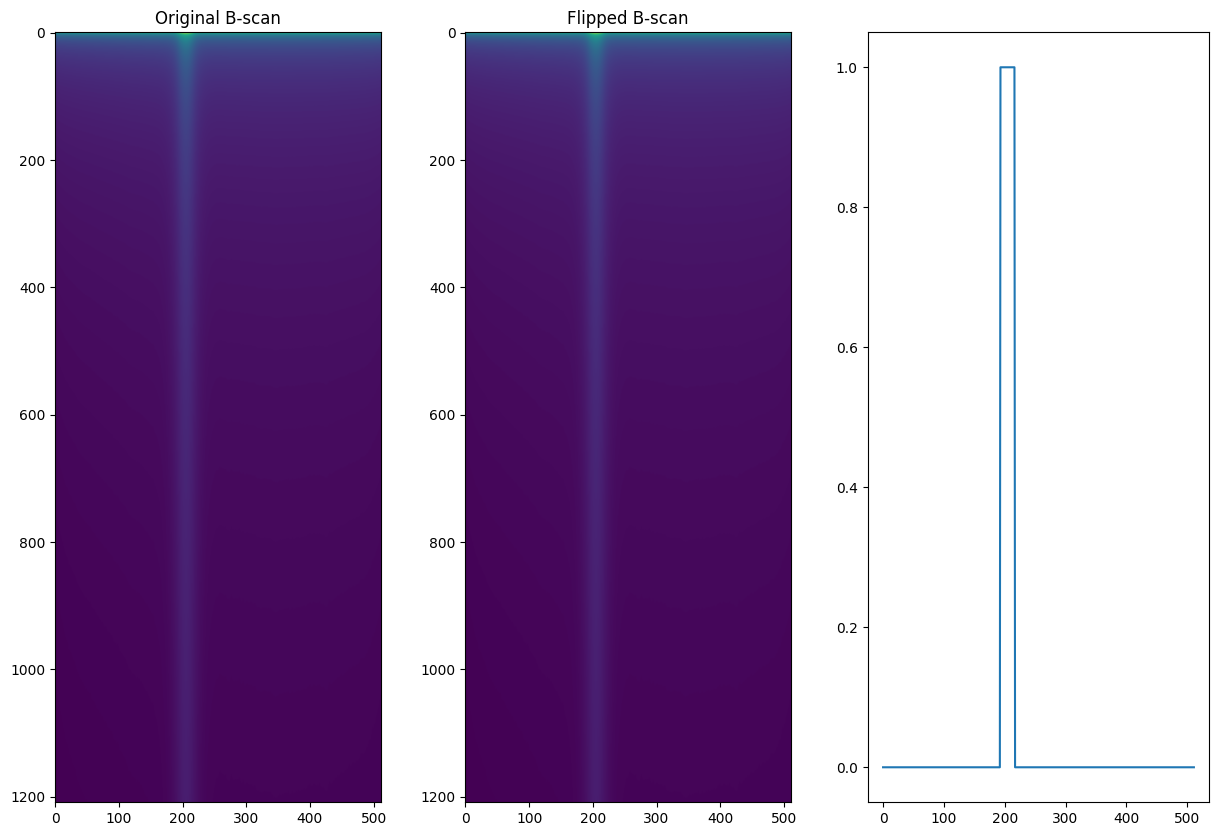

In [57]:
# bscan_noisy,depth=noise(bscan, data['mask'])
bscan_flipped,mask_flip=ranflip(bscan, mask)
plt.figure(figsize=(15,10))
plt.subplot(1,3,1)
plt.imshow(bscan)
plt.title("Original B-scan")
plt.subplot(1,3,2)
plt.imshow(bscan_flipped)
plt.title("Flipped B-scan")
plt.subplot(1,3,3)
plt.plot(mask_flip)